# Lab 05 - k-Nearest Neighbors Classifier
Project data: Sleep-EDF Database Expanded (subject SC4001E)  
Task: Classify 30-second PSG epochs into Sleep Stage N2 vs Sleep Stage N3 (deep sleep)

## Setup - install required packages

In [ ]:
!pip install mne -q

## Function definitions (single code block)

In [ ]:
import numpy as np
import mne
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier


def load_epoch_signals(psg_path, hypnogram_path, epoch_sec=30):
    raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
    annotations = mne.read_annotations(hypnogram_path)
    raw.set_annotations(annotations, emit_warning=False)

    sfreq = raw.info['sfreq']
    ch_names = [ch for ch in raw.ch_names if ch not in ('Event marker', 'Temp rectal')]
    data = raw.get_data(picks=ch_names)

    samples_per_epoch = int(epoch_sec * sfreq)
    epoch_signals = []
    epoch_labels = []

    for onset, duration, description in zip(annotations.onset, annotations.duration, annotations.description):
        n_sub_epochs = int(duration // epoch_sec)
        for i in range(n_sub_epochs):
            start_sample = int((onset + i * epoch_sec) * sfreq)
            end_sample = start_sample + samples_per_epoch
            if end_sample > data.shape[1]:
                continue
            epoch_signals.append(data[:, start_sample:end_sample])
            epoch_labels.append(description)

    return epoch_signals, epoch_labels, sfreq, ch_names


def band_power(signal_1d, sfreq, fmin, fmax):
    n = len(signal_1d)
    freqs = np.fft.rfftfreq(n, d=1.0 / sfreq)
    power_spectrum = np.abs(np.fft.rfft(signal_1d)) ** 2
    band_mask = (freqs >= fmin) & (freqs <= fmax)
    if not np.any(band_mask):
        return 0.0
    return float(np.mean(power_spectrum[band_mask]))


def extract_features_single_epoch(epoch_signal, sfreq):
    features = []
    n_channels = epoch_signal.shape[0]
    for ch_idx in range(n_channels):
        sig = epoch_signal[ch_idx]
        features.extend([
            np.mean(sig),
            np.std(sig),
            np.min(sig),
            np.max(sig),
            np.ptp(sig),
            np.sqrt(np.mean(sig ** 2)),
        ])
        if ch_idx < 2:
            features.append(band_power(sig, sfreq, 0.5, 4))
            features.append(band_power(sig, sfreq, 4, 8))
            features.append(band_power(sig, sfreq, 8, 13))
            features.append(band_power(sig, sfreq, 13, 30))
    return np.array(features)


def build_feature_matrix(epoch_signals, epoch_labels, sfreq, class_a, class_b):
    X, y = [], []
    for sig, label in zip(epoch_signals, epoch_labels):
        if label == class_a or label == class_b:
            X.append(extract_features_single_epoch(sig, sfreq))
            y.append(label)
    return np.array(X), np.array(y)


def encode_labels(y_raw):
    unique_labels = sorted(set(y_raw))
    label_to_int = {label: idx for idx, label in enumerate(unique_labels)}
    y_encoded = np.array([label_to_int[label] for label in y_raw])
    return y_encoded, label_to_int


def impute_missing_values(X, strategy='mean'):
    X_imputed = X.copy().astype(float)
    n_features = X_imputed.shape[1]

    for col in range(n_features):
        column = X_imputed[:, col]
        missing_mask = np.isnan(column)
        if not np.any(missing_mask):
            continue

        valid_values = column[~missing_mask]
        if strategy == 'mean':
            fill_value = np.mean(valid_values)
        elif strategy == 'median':
            fill_value = np.median(valid_values)
        elif strategy == 'mode':
            values, counts = np.unique(valid_values, return_counts=True)
            fill_value = values[np.argmax(counts)]
        else:
            raise ValueError("strategy must be 'mean', 'median', or 'mode'")

        X_imputed[missing_mask, col] = fill_value

    return X_imputed


def calculate_distance(point_a, point_b, metric='euclidean', p=3):
    diff = point_a - point_b
    if metric == 'euclidean':
        return np.sqrt(np.sum(diff ** 2))
    elif metric == 'manhattan':
        return np.sum(np.abs(diff))
    elif metric == 'minkowski':
        return np.sum(np.abs(diff) ** p) ** (1.0 / p)
    else:
        raise ValueError("metric must be 'euclidean', 'manhattan', or 'minkowski'")


def bubble_sort(distances, indices):
    dist = distances.copy()
    idx = indices.copy()
    n = len(dist)
    for i in range(n):
        for j in range(0, n - i - 1):
            if dist[j] > dist[j + 1]:
                dist[j], dist[j + 1] = dist[j + 1], dist[j]
                idx[j], idx[j + 1] = idx[j + 1], idx[j]
    return dist, idx


def merge_sort(distances, indices):
    if len(distances) <= 1:
        return distances, indices

    mid = len(distances) // 2
    left_d, left_i = merge_sort(distances[:mid], indices[:mid])
    right_d, right_i = merge_sort(distances[mid:], indices[mid:])

    merged_d, merged_i = [], []
    li, ri = 0, 0
    while li < len(left_d) and ri < len(right_d):
        if left_d[li] <= right_d[ri]:
            merged_d.append(left_d[li]); merged_i.append(left_i[li]); li += 1
        else:
            merged_d.append(right_d[ri]); merged_i.append(right_i[ri]); ri += 1
    merged_d.extend(left_d[li:]); merged_i.extend(left_i[li:])
    merged_d.extend(right_d[ri:]); merged_i.extend(right_i[ri:])

    return np.array(merged_d), np.array(merged_i)


def quick_sort(distances, indices):
    if len(distances) <= 1:
        return distances, indices

    pivot = distances[len(distances) // 2]
    left_mask = distances < pivot
    equal_mask = distances == pivot
    right_mask = distances > pivot

    left_d, left_i = quick_sort(distances[left_mask], indices[left_mask])
    right_d, right_i = quick_sort(distances[right_mask], indices[right_mask])

    sorted_d = np.concatenate([left_d, distances[equal_mask], right_d])
    sorted_i = np.concatenate([left_i, indices[equal_mask], right_i])
    return sorted_d, sorted_i


SORTING_ALGORITHMS = {
    'bubble': bubble_sort,
    'merge': merge_sort,
    'quick': quick_sort,
}


def get_k_neighbors(distances, k, sort_algorithm='quick'):
    indices = np.arange(len(distances))
    sort_fn = SORTING_ALGORITHMS[sort_algorithm]
    sorted_distances, sorted_indices = sort_fn(np.array(distances, dtype=float), indices)
    return sorted_indices[:k], sorted_distances[:k]


def majority_vote(neighbor_labels, neighbor_distances=None, weighted=False):
    unique_labels = np.unique(neighbor_labels)

    if weighted and neighbor_distances is not None:
        scores = {}
        eps = 1e-6
        for label in unique_labels:
            mask = neighbor_labels == label
            scores[label] = np.sum(1.0 / (neighbor_distances[mask] + eps))
    else:
        scores = {label: np.sum(neighbor_labels == label) for label in unique_labels}

    max_score = max(scores.values())
    tied_labels = [label for label, score in scores.items() if score == max_score]

    if len(tied_labels) == 1:
        return tied_labels[0]

    for idx in np.argsort(neighbor_distances):
        if neighbor_labels[idx] in tied_labels:
            return neighbor_labels[idx]
    return tied_labels[0]


class CustomKNNClassifier:

    def __init__(self, k=3, distance_metric='euclidean', sort_algorithm='quick',
                 minkowski_p=3, weighted=False):
        self.k = k
        self.distance_metric = distance_metric
        self.sort_algorithm = sort_algorithm
        self.minkowski_p = minkowski_p
        self.weighted = weighted
        self.X_train = None
        self.y_train = None

    def fit(self, X_train, y_train):
        self.X_train = np.array(X_train, dtype=float)
        self.y_train = np.array(y_train)
        return self

    def _predict_single(self, x_query):
        distances = np.array([
            calculate_distance(x_query, x_train_point, self.distance_metric, self.minkowski_p)
            for x_train_point in self.X_train
        ])
        neighbor_idx, neighbor_dist = get_k_neighbors(distances, self.k, self.sort_algorithm)
        neighbor_labels = self.y_train[neighbor_idx]
        return majority_vote(neighbor_labels, neighbor_dist, weighted=self.weighted)

    def predict(self, X_test):
        X_test = np.array(X_test, dtype=float)
        return np.array([self._predict_single(x) for x in X_test])

    def score(self, X_test, y_test):
        y_pred = self.predict(X_test)
        return float(np.mean(y_pred == np.array(y_test)))


## Main program

Loading PSG epochs and extracting features...


/tmp/ipykernel_480/3792391837.py:8: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
/tmp/ipykernel_480/3792391837.py:8: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
/tmp/ipykernel_480/3792391837.py:8: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
/tmp/ipykernel_480/3792391837.py:8: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)


Channels used: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal', 'EMG submental']
Total epochs for 'Sleep stage 2' vs 'Sleep stage 3': 351, feature dim: 38
Class distribution: Sleep stage 2=250, Sleep stage 3=101

Encoded classes: {np.str_('Sleep stage 2'): 0, np.str_('Sleep stage 3'): 1}

Imputation check - NaNs before: 5, after: 0

Train size: 245, Test size: 106

[sklearn] KNN (k=3) test accuracy: 0.6226
[sklearn] Sample predictions: [0 0 0 0 0 0 0 0 0 1]

[custom] KNN (k=3) test accuracy: 0.6226
[custom] Sample predictions: [0 0 0 0 0 0 0 0 0 1]
[custom-weighted] KNN (k=3) test accuracy: 0.6226


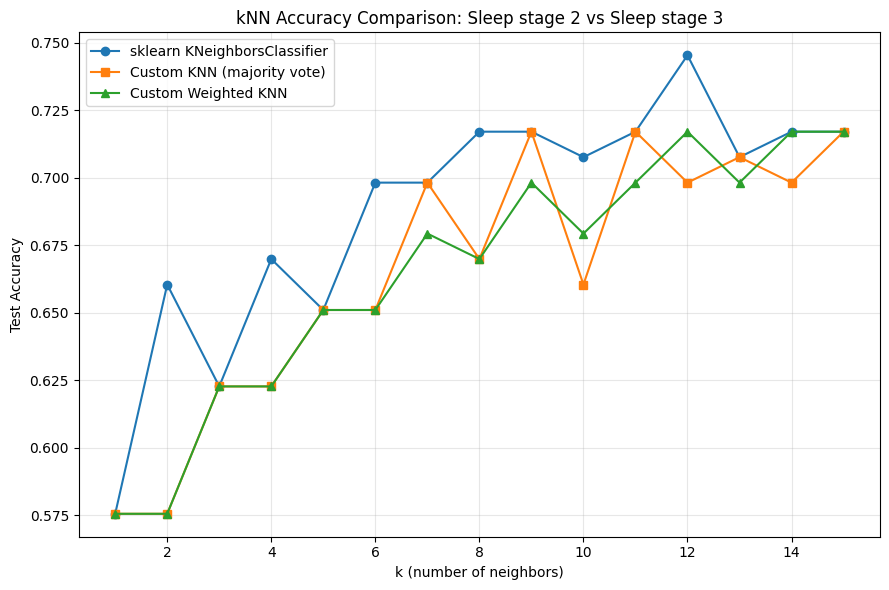

[bubble_sort] sorted distances: [0.5 1.1 1.1 3.3 5.2 8. ]
[merge_sort] sorted distances: [0.5 1.1 1.1 3.3 5.2 8. ]
[quick_sort] sorted distances: [0.5 1.1 1.1 3.3 5.2 8. ]


In [ ]:
import matplotlib.pyplot as plt

import glob

PSG_PATH = glob.glob('/content/*PSG*.edf')[0]
HYPNOGRAM_PATH = glob.glob('/content/*Hypnogram*.edf')[0]
CLASS_A = 'Sleep stage 2'
CLASS_B = 'Sleep stage 3'

print("Loading PSG epochs and extracting features...")
epoch_signals, epoch_labels, sfreq, ch_names = load_epoch_signals(PSG_PATH, HYPNOGRAM_PATH)
X_raw, y_raw = build_feature_matrix(epoch_signals, epoch_labels, sfreq, CLASS_A, CLASS_B)
print(f"Channels used: {ch_names}")
print(f"Total epochs for '{CLASS_A}' vs '{CLASS_B}': {X_raw.shape[0]}, feature dim: {X_raw.shape[1]}")
print(f"Class distribution: {CLASS_A}={np.sum(y_raw == CLASS_A)}, {CLASS_B}={np.sum(y_raw == CLASS_B)}")

y_encoded, label_to_int = encode_labels(y_raw)
print(f"\nEncoded classes: {label_to_int}")

X_demo = X_raw.copy()
rng = np.random.default_rng(seed=42)
nan_rows = rng.choice(X_demo.shape[0], size=min(5, X_demo.shape[0]), replace=False)
X_demo[nan_rows, 0] = np.nan
X_imputed = impute_missing_values(X_demo, strategy='mean')
print(f"\nImputation check - NaNs before: {np.isnan(X_demo).sum()}, after: {np.isnan(X_imputed).sum()}")

X = X_raw

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)
print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

sk_knn = KNeighborsClassifier(n_neighbors=3)
sk_knn.fit(X_train, y_train)
sk_accuracy = sk_knn.score(X_test, y_test)
sk_predictions = sk_knn.predict(X_test)
print(f"\n[sklearn] KNN (k=3) test accuracy: {sk_accuracy:.4f}")
print(f"[sklearn] Sample predictions: {sk_predictions[:10]}")

custom_knn = CustomKNNClassifier(k=3, distance_metric='euclidean', sort_algorithm='quick')
custom_knn.fit(X_train, y_train)
custom_accuracy = custom_knn.score(X_test, y_test)
custom_predictions = custom_knn.predict(X_test)
print(f"\n[custom] KNN (k=3) test accuracy: {custom_accuracy:.4f}")
print(f"[custom] Sample predictions: {custom_predictions[:10]}")

weighted_knn = CustomKNNClassifier(k=3, distance_metric='euclidean', sort_algorithm='quick', weighted=True)
weighted_knn.fit(X_train, y_train)
weighted_accuracy = weighted_knn.score(X_test, y_test)
print(f"[custom-weighted] KNN (k=3) test accuracy: {weighted_accuracy:.4f}")

k_values = range(1, 16)
sklearn_accuracies, custom_accuracies, weighted_accuracies_list = [], [], []

for k in k_values:
    sk_model = KNeighborsClassifier(n_neighbors=k)
    sk_model.fit(X_train, y_train)
    sklearn_accuracies.append(sk_model.score(X_test, y_test))

    c_model = CustomKNNClassifier(k=k, sort_algorithm='quick')
    c_model.fit(X_train, y_train)
    custom_accuracies.append(c_model.score(X_test, y_test))

    w_model = CustomKNNClassifier(k=k, sort_algorithm='quick', weighted=True)
    w_model.fit(X_train, y_train)
    weighted_accuracies_list.append(w_model.score(X_test, y_test))

plt.figure(figsize=(9, 6))
plt.plot(list(k_values), sklearn_accuracies, marker='o', label='sklearn KNeighborsClassifier')
plt.plot(list(k_values), custom_accuracies, marker='s', label='Custom KNN (majority vote)')
plt.plot(list(k_values), weighted_accuracies_list, marker='^', label='Custom Weighted KNN')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Test Accuracy')
plt.title(f'kNN Accuracy Comparison: {CLASS_A} vs {CLASS_B}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

sample_distances = np.array([5.2, 1.1, 3.3, 1.1, 8.0, 0.5])
sample_indices = np.arange(len(sample_distances))
for algo_name, algo_fn in SORTING_ALGORITHMS.items():
    sorted_d, sorted_i = algo_fn(sample_distances.copy(), sample_indices.copy())
    print(f"[{algo_name}_sort] sorted distances: {sorted_d}")
